# Feature Engineering: df_ml Preparation
Create ML-ready dataset from df_video with feature engineering

## 1. Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_video = pd.read_csv(r"D:\KLTN\analysis\data\cleaned_video.csv")
pd.set_option('display.max_columns', None)
print(f"Original shape: {df_video.shape}")

Original shape: (1171108, 45)


In [4]:
df_video

,video_id,views,likes,comments,snapshot_time,is_trending,channel_id,time_id,source,title,description,publish_time,thumbnail,keyword,topic,duration_seconds,definition,caption,licensed_content,category_id,default_language,default_audio_language,tags,channel_title,custom_url,channel_description,channel_created_at,country,subscriber_count,view_count,video_count,date,year,quarter,month,week_of_year,day,weekday,hour,country_region,like_rate,comment_rate,publish_weekday,publish_hour,snapshot_weekday
0,atJwRQ1zdjQ,350781,35288,2980,2026-05-13 06:46:25.134504+00:00,True,UCUs8sGiP4avNaYNVO22INhQ,2026051216,trending,mgk & Wiz Khalifa - girl next door (Official M...,Watch the official music video for mgk & @wizk...,2026-05-12 16:00:06+00:00,https://i.ytimg.com/vi/atJwRQ1zdjQ/default.jpg,trending,music,237,hd,False,False,10,en,Unknown,"mgk,wiz khalifa,girl next door,blog era boyz,b...",mgk,@mgk,Unknown,2006-12-27T05:10:50Z,US,9470000,6778467533,390,2026-05-12,2026,2,5,20,12,1,16,North America,0.100598,0.008495,Tuesday,16,Wednesday
1,CnmcXIdMZ2Q,3244,54,4,2026-05-13 06:46:25.134504+00:00,False,UC-ik3qPQU2SQyzzAY5f_v7g,2026051301,search,"GILA! Veda Ega Pratama Bikin Dunia Shock, Indo...",Veda Ega Pratama kembali bikin dunia balap geg...,2026-05-13 01:19:00+00:00,https://i.ytimg.com/vi/CnmcXIdMZ2Q/default.jpg,motogp highlights,sports,29,hd,False,False,17,id,id,"veda ega pratama,\nveda ega moto3,\nmoto3 2026...",GLORA MOTOR,@gloramotor-k3,selamat datang di channel yang membahas panasn...,2025-11-15T14:50:48.636622Z,Unknown,1130,1262324,134,2026-05-13,2026,2,5,20,13,2,1,Southeast Asia,0.016646,0.001233,Wednesday,1,Wednesday
2,fNEGWXFmZcU,1709706,38087,1247,2026-05-13 06:46:25.134504+00:00,False,UCB_qr75-ydFVKSF9Dmo6izg,2026031306,search,FP1 Highlights | 2026 Chinese Grand Prix,Catch up on all the highlights from the sole p...,2026-03-13 06:01:00+00:00,https://i.ytimg.com/vi/fNEGWXFmZcU/default.jpg,formula 1 highlights,sports,300,hd,False,True,17,en,en,"F1,Formula One,Formula 1,Sports,Sport,Action,G...",FORMULA 1,@formula1,2026 - It's All To Drive For\n,2005-12-29T00:34:38Z,Unknown,14600000,9663626695,10069,2026-03-13,2026,1,3,11,13,4,6,Unknown,0.022277,0.000729,Friday,6,Wednesday
3,jL56ArZGc14,902,8,0,2026-05-13 06:46:25.134504+00:00,False,UChJQ9QWkZX28Rb8UwbD3vqg,2026031408,search,2026 China Grand Prix I Sprint Race Highlights...,Sprint Highlights | 2026 Chinese Grand Prix Ke...,2026-03-14 08:47:57+00:00,https://i.ytimg.com/vi/jL56ArZGc14/default.jpg,formula 1 highlights,sports,35,hd,False,False,2,en,Unknown,"#f1,#formula1,#f1sprint",MotoGenic,@motogenicrr,I created this channel to upload good quality ...,2011-10-12T07:38:31Z,Unknown,161,166307,133,2026-03-14,2026,1,3,11,14,5,8,Unknown,0.008869,0.000000,Saturday,8,Wednesday
4,ENqY3GeF1TM,11890,314,2,2026-05-13 06:46:25.134504+00:00,False,UCGtU-xV4vCM9bFoOwI16q9A,2026031409,search,Alonso 2026 highlights - F1 2026 | #f1 #alonso...,charlesleclerc #maxverstappen #alonso #lewisha...,2026-03-14 09:00:29+00:00,https://i.ytimg.com/vi/ENqY3GeF1TM/default.jpg,formula 1 highlights,sports,11,hd,False,False,17,it,en-US,Unknown,Daliots Sport,@liotts-sport,🏎️⚽ Benvenuti nel canale sport di Daliots!\n\n...,2024-12-21T15:54:51.992711Z,IT,1580,3197998,69,2026-03-14,2026,1,3,11,14,5,9,Western Europe,0.026409,0.000168,Saturday,9,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171103,vNVCWW0Cbt0,78907,818,28,2026-05-24 13:43:12.320594+00:00,True,UC9-yZkJfxtg6WNCX5mUQb0w,2026051409,trending,【ドラクエウォーク】ヘルガイオンの弱点とソロ安定攻略法！この構成でセミオートで楽勝です！,ヘルガイオンのオート攻略法を紹介！\n---------------------------...,2026-05-14 09:03:01+00:00,https://i.ytimg.com/vi/vNVCWW0Cbt0/default.jpg,trending,gaming,798,hd,False,True,20,ja,ja,"ドラクエウォーク,ドラクエ,DQウォーク,ドラゴンクエストウォーク,DQW,スマートウォーク...",ノゴローチャンネル,@nogoro_dq,ドラクエウォークのゲーム実況をしています！,2015-03-21T11:00:35Z,JP,129000,197872459,3885,2026-05-14,2026,2,5,20,14,3,9,East 

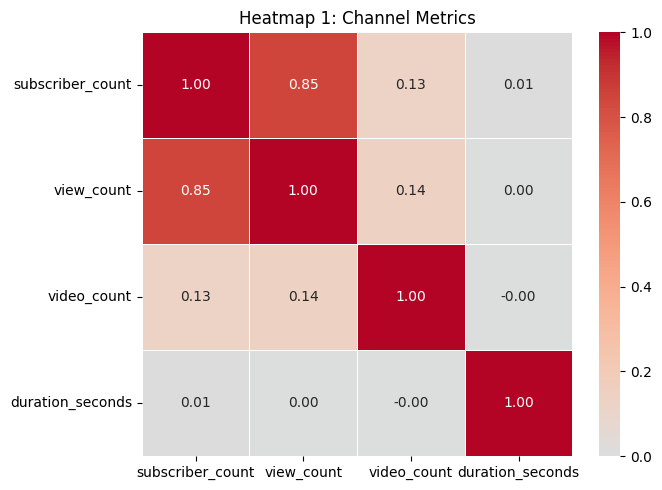

In [5]:
cols_hm1 = ["subscriber_count", "view_count", "video_count", "duration_seconds"]
corr_hm1 = df_video[cols_hm1].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_hm1, cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
plt.title("Heatmap 1: Channel Metrics")
plt.tight_layout()
plt.show()

subscriber_count & view_count =  tương quan mạnh

giữ 1 trong 2 đưa vào ML

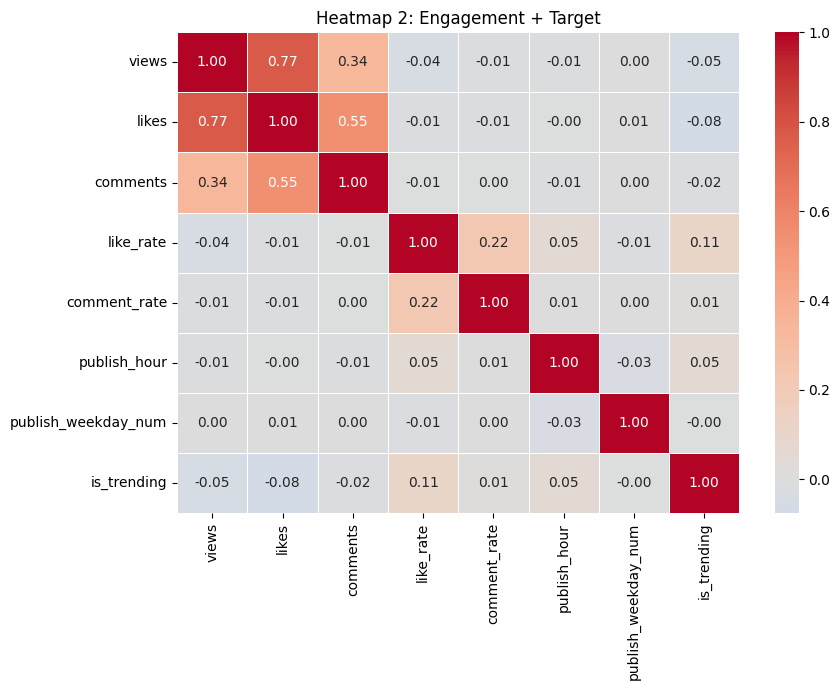

In [6]:
# tao tam cac cot can thiet neu chua co
df_hm2 = df_video.copy()
df_hm2["publish_time"] = pd.to_datetime(df_hm2["publish_time"], errors="coerce")
df_hm2["publish_hour"] = df_hm2["publish_time"].dt.hour
df_hm2["publish_weekday_num"] = df_hm2["publish_time"].dt.dayofweek
df_hm2["like_rate"] = df_hm2["likes"] / df_hm2["views"]
df_hm2["comment_rate"] = df_hm2["comments"] / df_hm2["views"]

cols_hm2 = [
    "views", "likes", "comments",
    "like_rate", "comment_rate",
    "publish_hour", "publish_weekday_num",
    "is_trending"
]
corr_hm2 = df_hm2[cols_hm2].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_hm2, cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
plt.title("Heatmap 2: Engagement + Target")
plt.tight_layout()
plt.show()

giữ like_rate, publish_hour 

## 2. Data Preprocessing (same as eda)

In [7]:
# Type conversion
df_video["snapshot_time"] = pd.to_datetime(df_video["snapshot_time"], errors="coerce")
df_video["publish_time"] = pd.to_datetime(df_video["publish_time"], errors="coerce")
df_video["channel_created_at"] = pd.to_datetime(df_video["channel_created_at"], errors="coerce")
df_video["date"] = pd.to_datetime(df_video["date"], errors="coerce")
df_video["is_trending"] = df_video["is_trending"].astype(bool)
df_video["duration_seconds"] = df_video["duration_seconds"].astype("Int64")
df_video["category_id"] = df_video["category_id"].astype("Int64")
df_video["subscriber_count"] = df_video["subscriber_count"].astype("Int64")
df_video["view_count"] = df_video["view_count"].astype("Int64")
df_video["video_count"] = df_video["video_count"].astype("Int64")

# Handle nulls
df_video["description"] = df_video["description"].fillna("Unknown")
df_video["tags"] = df_video["tags"].fillna("Unknown")
df_video["default_language"] = df_video["default_language"].fillna("Unknown")
df_video["default_audio_language"] = df_video["default_audio_language"].fillna("Unknown")
df_video["channel_title"] = df_video["channel_title"].fillna("Unknown")
df_video["custom_url"] = df_video["custom_url"].fillna("Unknown")
df_video["channel_description"] = df_video["channel_description"].fillna("Unknown")
df_video["country"] = df_video["country"].fillna("Unknown")

df_video = df_video.dropna(subset=["video_count", "view_count"])

# Filtering
df_video = df_video[
    (df_video["views"] > 0) &
    (df_video["likes"] <= df_video["views"])
].copy()

df_video["like_rate"] = df_video["likes"] / df_video["views"]
df_video["comment_rate"] = df_video["comments"] / df_video["views"]

print("Preprocessing done!")

Preprocessing done!


## 3. Add Time Features

In [8]:
df_video["publish_hour"] = df_video["publish_time"].dt.hour
df_video["publish_weekday"] = df_video["publish_time"].dt.day_name()

# Convert weekday names to numbers for categorical
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df_video["publish_weekday_num"] = df_video["publish_weekday"].map(
    {day: i for i, day in enumerate(weekday_order)}
)

print("Time features added!")

Time features added!


## 4. Create df_ml (First Snapshot per Video)

In [9]:
# Sort by snapshot_time and take first snapshot per video
# This avoids data leakage - we use only the earliest available data
df_ml = df_video.sort_values("snapshot_time").groupby("video_id").first().reset_index()

print(f"df_ml shape: {df_ml.shape}")
print(f"Unique videos: {df_ml['video_id'].nunique()}")
print(f"\nTrending distribution:")
print(df_ml['is_trending'].value_counts())
print(f"Trending rate: {df_ml['is_trending'].mean()*100:.1f}%")

df_ml shape: (158073, 46)
Unique videos: 158073

Trending distribution:
is_trending
False    117310
True      40763
Name: count, dtype: int64
Trending rate: 25.8%


## 5. Feature Quality Checks

In [10]:
print("Missing values:")
print(df_ml[["subscriber_count", "view_count", "video_count"]].isna().sum())

print("\nStatistics:")
print(df_ml[["subscriber_count", "view_count", "video_count"]].describe())

Missing values:
subscriber_count    0
view_count          0
video_count         0
dtype: int64

Statistics:
       subscriber_count         view_count   video_count
count          158073.0           158073.0      158073.0
mean     1875807.758631  1077859453.010388    1890.61068
std       9657064.09992   7292104768.84804  12942.407949
min                 0.0                0.0           0.0
25%              3130.0          1243598.0         106.0
50%             78500.0         30422766.0         401.0
75%            755000.0        299926843.0        1257.0
max         490000000.0     342248673596.0      663115.0


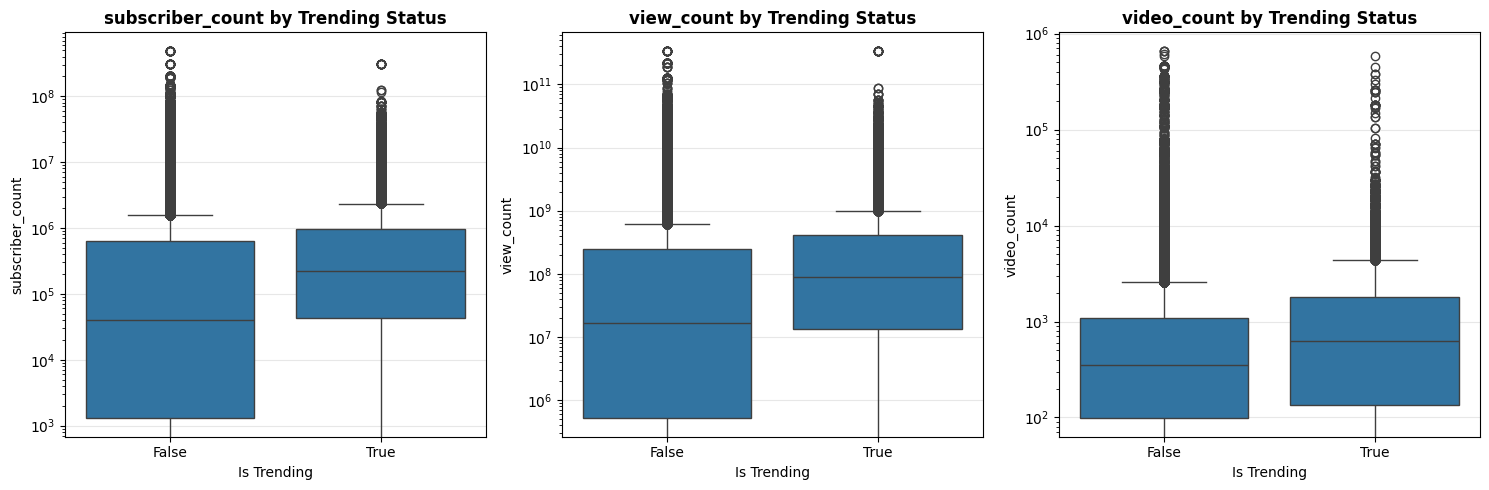

Note: These features need feature engineering before using in ML models.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(["subscriber_count", "view_count", "video_count"]):
    sns.boxplot(data=df_ml, x="is_trending", y=col, ax=axes[idx])
    axes[idx].set_title(f"{col} by Trending Status", fontsize=12, weight="bold")
    axes[idx].set_xlabel("Is Trending")
    axes[idx].set_ylabel(col)
    axes[idx].set_yscale("log")
    axes[idx].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: These features need feature engineering before using in ML models.")

## 6. Analyze Predictive Features

In [12]:
print("=== Publish Hour Impact ===")
hour_impact = df_ml.groupby("publish_hour")["is_trending"].agg(["sum", "count", "mean"])
print(hour_impact.sort_values("mean", ascending=False).head(10))

print("\n=== Publish Weekday Impact ===")
weekday_impact = df_ml.groupby("publish_weekday")["is_trending"].agg(["sum", "count", "mean"])
print(weekday_impact.sort_values("mean", ascending=False))

=== Publish Hour Impact ===
               sum  count      mean
publish_hour                       
10            3316   8557  0.387519
22            1556   4646  0.334912
9             2196   6678  0.328841
21            1482   4915  0.301526
16            2583   9121  0.283193
23            1202   4291  0.280121
11            2781   9999  0.278128
8             1472   5456  0.269795
15            2804  10446  0.268428
17            1920   7241  0.265157

=== Publish Weekday Impact ===
                  sum  count      mean
publish_weekday                       
Friday           6911  24036  0.287527
Saturday         5767  20080  0.287201
Thursday         7264  26118  0.278122
Tuesday          6235  25144  0.247972
Sunday           4761  19225  0.247646
Wednesday        5830  24229  0.240621
Monday           3995  19241  0.207630


In [13]:
print("\n=== Duration Correlation ===")
print(df_ml[["duration_seconds", "is_trending"]].corr())

print("\n=== Category Impact ===")
category_impact = df_ml.groupby("category_id")["is_trending"].agg(["sum", "count", "mean"])
print(category_impact.sort_values("mean", ascending=False).head(10))


=== Duration Correlation ===
                  duration_seconds  is_trending
duration_seconds          1.000000    -0.000694
is_trending              -0.000694     1.000000

=== Category Impact ===
               sum  count      mean
category_id                        
20           25700  47398  0.542217
10            9506  18996  0.500421
1              382   3310  0.115408
24            1859  16966  0.109572
29              11    110  0.100000
2               29    294  0.098639
22            2852  41144  0.069318
25              43    719  0.059805
23             122   2204  0.055354
17             110   5237  0.021004


In [14]:
print("\n=== Definition Impact ===")
print(df_ml.groupby("definition")["is_trending"].agg(["sum", "count", "mean"]))

print("\n=== Caption Impact ===")
print(df_ml.groupby("caption")["is_trending"].agg(["sum", "count", "mean"]))


=== Definition Impact ===
              sum   count      mean
definition                         
hd          40576  157180  0.258150
sd            187     893  0.209406

=== Caption Impact ===
           sum   count      mean
caption                         
False    39408  150767  0.261383
True      1355    7306  0.185464


## 7. Feature Engineering

## 8. Feature Summary

## 9. Data Quality Check

In [15]:
print(f"Total rows: {len(df_ml)}")
print(f"\nMissing values:")
print(df_ml.isnull().sum())

print(f"\nDuplicates: {df_ml.duplicated().sum()}")

Total rows: 158073

Missing values:
video_id                      0
views                         0
likes                         0
comments                      0
snapshot_time                 0
is_trending                   0
channel_id                    0
time_id                       0
source                        0
title                         0
description                   0
publish_time                  0
thumbnail                     0
keyword                       0
topic                         0
duration_seconds              0
definition                    0
caption                       0
licensed_content              0
category_id                   0
default_language              0
default_audio_language        0
tags                          0
channel_title                 0
custom_url                    0
channel_description           0
channel_created_at        93811
country                       0
subscriber_count              0
view_count                    0
vide

In [16]:
df_ml

,video_id,views,likes,comments,snapshot_time,is_trending,channel_id,time_id,source,title,description,publish_time,thumbnail,keyword,topic,duration_seconds,definition,caption,licensed_content,category_id,default_language,default_audio_language,tags,channel_title,custom_url,channel_description,channel_created_at,country,subscriber_count,view_count,video_count,date,year,quarter,month,week_of_year,day,weekday,hour,country_region,like_rate,comment_rate,publish_weekday,publish_hour,snapshot_weekday,publish_weekday_num
0,---k1vFBbWw,1061038,24510,349,2026-05-19 14:41:30.025230+00:00,False,UCpQ34afVgk8cRQBjSJ1xuJQ,2023080115,search,12 MIN SLOW &amp; INTENSE ABS - Workout for De...,Try this slow & intense 12 min TOTAL CORE work...,2023-08-01 15:09:21+00:00,https://i.ytimg.com/vi/---k1vFBbWw/default.jpg,abs workout,fitness,809,hd,False,True,22,en,en,"slow and intense abs,defined abs workout,no eq...",MadFit,@madfit,"This is a place where I post REAL TIME, AT HOM...",2018-03-02 01:46:06+00:00,CA,11400000,1617557672,1385,2023-08-01,2023,3,8,31,1,1,15,North America,0.023100,0.000329,Tuesday,15,Tuesday,1
1,--0NZjUvuKs,265108,16110,310,2026-05-13 06:46:25.134504+00:00,False,UCgmdMwVR6MLaJOLgE6c1q7Q,2026042219,search,CLAYFACE TRAILER IS TERRIFYING… (New DC Film),Unknown,2026-04-22 19:37:14+00:00,https://i.ytimg.com/vi/--0NZjUvuKs/default.jpg,dc trailer,entertainment,63,hd,False,True,1,en,en,Unknown,VETZ,@vetzmovies,I rank and review movies - all socials @vetzmo...,2019-03-30 00:43:29+00:00,US,350000,757675886,2266,2026-04-22,2026,2,4,17,22,2,19,North America,0.060768,0.001169,Wednesday,19,Wednesday,2
2,--ASSQxzhPE,711646,13848,245,2026-05-14 07:35:04.860906+00:00,False,UCwQy5xNCIjlpK6wUqUMEHeA,2024012004,search,C4 Gaming Cân 8 😱😱😱 #shorts,C4 Gaming Cân 8 #shorts #freefire #tngaming.,2024-01-20 04:54:32+00:00,https://i.ytimg.com/vi/--ASSQxzhPE/default.jpg,gaming highlights,gaming,57,hd,False,False,20,vi,vi,"c4 gaming,c4 free fire,c4 ff,c4 gaming ff,cu t...",TN GAMING,@tngaming88,Đây là kênh chính thức của TN GAMING\n✔ ĐĂNG K...,NaT,VN,523000,27968101,144,2024-01-20,2024,1,1,3,20,5,4,Southeast Asia,0.019459,0.000344,Saturday,4,Thursday,5
3,--Avak9eZ_0,1274103,98981,114,2026-05-15 09:03:31.822596+00:00,False,UCxaZ0oJZJlRQ8wQihzwzsWg,2025091311,search,"60 Minutes Ultimate Make Up Playset, Satisfyin...","60 Minutes Ultimate Make Up Playset, Satisfyin...",2025-09-13 11:46:41+00:00,https://i.ytimg.com/vi/--Avak9eZ_0/default.jpg,toy review,kids,3625,hd,False,False,22,en,en-US,"Tina Unboxing,tina unboxing,unboxing,ASMR,unbo...",Tina Unboxing Toys,@tinaunboxingtoys,Welcome to the Tina Unboxing Toys channel! 💖💖\...,NaT,US,556000,83566008,242,2025-09-13,2025,3,9,37,13,5,11,North America,0.077687,0.000089,Saturday,11,Friday,5
4,--CKzGfPWn0,3481191,31634,514,2026-05-21 15:45:47.654518+00:00,False,UCAj9nn-gOcKuD4ropg44HCw,2024122816,search,🔥 Hot Right Now - Best of 2024 | Best Hip Hop ...,The best Hip Hop and R&B songs of 2024 in the ...,2024-12-28 16:00:00+00:00,https://i.ytimg.com/vi/--CKzGfPWn0/default.jpg,hip hop mix,music,4324,hd,False,False,10,en,zxx,"playlist,remix,mix,mixtape,black music,hip hop...",DJ Noize,@djnoizemusic,"Weekly Hip Hop, R&B, Dancehall and Trap mixes....",2011-02-28 22:56:18+00:00,DE,1250000,369421974,425,2024-12-28,2024,4,12,52,28,5,16,Western Europe,0.009087,0.000148,Saturday,16,Thursday,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158068,zzv3JoHplQo,1236,290,58,2026-05-20 06:26:58.908982+00:00,True,UC4e6BuJm74UBdpOjdO2iNfw,2026052004,trending,PARADOJA DE BERKLEY - EL TEMACH X NASTY KILLAH...,DIR. & FOTO X GABO DIRECTOR\nX COMBATE MILITANTE,2026-05-20 04:00:46+00:00,https://i.ytimg.com/vi/zzv3JoHplQo/default.jpg,trending,people,139,hd,False,True,22,es,es-MX,Unknown,Combate Militante,@combatemilitante,Productora Audiovisual — Hecho en México\n,NaT,MX,32900,2959259,18,2026-05-20,2026,2,5,2

## 10. Select ML Features & Save

In [17]:
# Select features for ML
ml_features = [
    "video_id", 
    "channel_id",
    "subscriber_count", "view_count", "video_count",
    "like_rate", 
    "comment_rate",
    "duration_seconds",
    "topic", 
    "country_region",
    "is_trending"
]

df_ml_final = df_ml[ml_features].copy()

print(f"ML Dataset shape: {df_ml_final.shape}")
print(f"\nColumns:")
print(df_ml_final.columns.tolist())

ML Dataset shape: (158073, 11)

Columns:
['video_id', 'channel_id', 'subscriber_count', 'view_count', 'video_count', 'like_rate', 'comment_rate', 'duration_seconds', 'topic', 'country_region', 'is_trending']


In [18]:
# Save to CSV
output_path = r"D:\KLTN\analysis\data\ml_dataset.csv"
df_ml_final.to_csv(output_path, index=False)
print(f"ML dataset saved to: {output_path}")

print(f"\nDataset Info:")
print(f"Rows: {len(df_ml_final)}")
print(f"Columns: {len(df_ml_final.columns)}")
print(f"\nTarget variable distribution:")
print(df_ml_final['is_trending'].value_counts())
print(f"Class balance: {df_ml_final['is_trending'].mean()*100:.1f}% trending")

ML dataset saved to: D:\KLTN\analysis\data\ml_dataset.csv

Dataset Info:
Rows: 158073
Columns: 11

Target variable distribution:
is_trending
False    117310
True      40763
Name: count, dtype: int64
Class balance: 25.8% trending
